# Experiment 1: Data Preprocessing

Dataset: Iris dataset

## a) Load the dataset, encode labels, scale features, and reshape for 1D CNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import os

if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Load dataset
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
data = pd.read_csv("../iris/iris.data", header=None, names=columns)

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(data["species"])
y_cat = to_categorical(y)
X = data.drop("species", axis=1).values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for 1D CNN (samples, features, channels)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print("Preprocessing and reshaping complete.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")

Preprocessing and reshaping complete.
X_train_reshaped shape: (120, 4, 1)


# Experiment 2: CNN Implementation

## b) Design and train a 1D Convolutional Neural Network (CNN)

In [2]:
# Build CNN model
model = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(4, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train_reshaped, y_train, epochs=50, batch_size=5, verbose=0, validation_split=0.1)

print("CNN training complete.")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN training complete.


# Experiment 3: Performance Evaluation

## c) Evaluate the model using Accuracy, Confusion Matrix, and Classification Report

In [3]:
# Predictions
y_pred_prob = model.predict(X_test_reshaped)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


Accuracy: 0.9000

Confusion Matrix:
 [[10  0  0]
 [ 1  8  0]
 [ 2  0  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.89      0.94         9
           2       1.00      0.82      0.90        11

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



# Experiment 4: Visualization

## d) Visualize the Training Progress (Accuracy & Loss) and Confusion Matrix

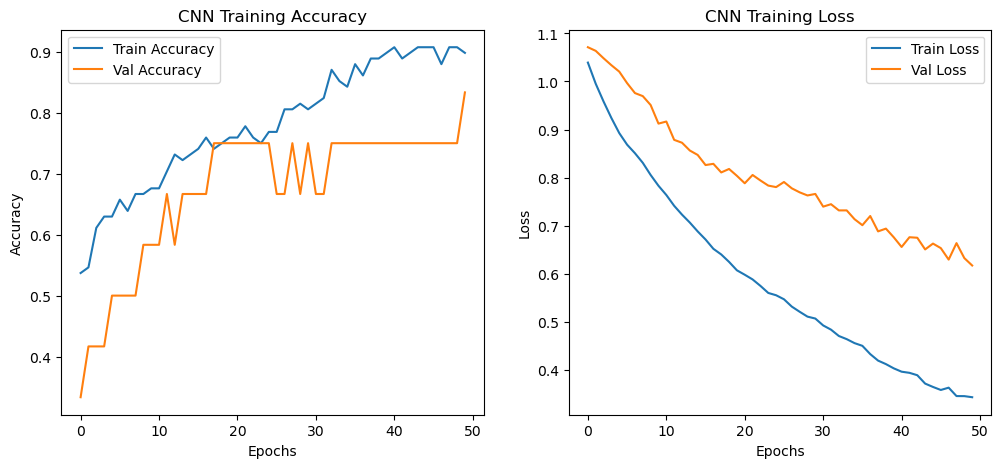

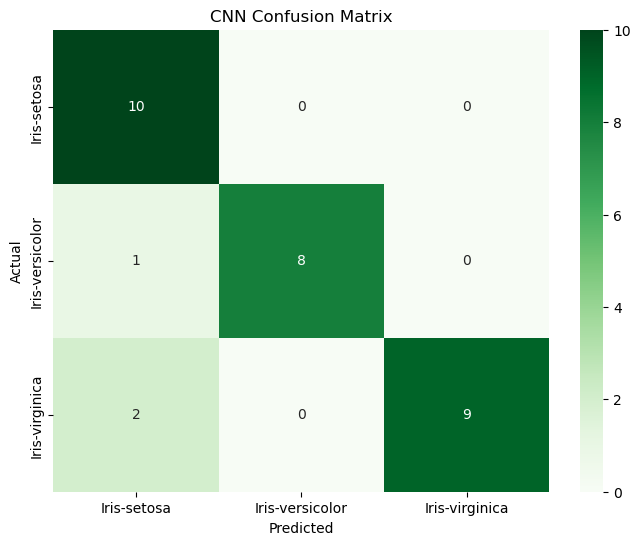

In [4]:
# Plotting Training History
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig('outputs/training_history.png')
plt.show()

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN Confusion Matrix')
plt.savefig('outputs/confusion_matrix.png')
plt.show()

# Questions:

1. **What is a Convolutional Neural Network (CNN)?**
   A CNN is a type of deep neural network most commonly used for analyzing visual imagery. However, it can also be applied to 1D data (like sequences or fixed-size feature vectors) to extract local patterns using convolution filters.

2. **What is the purpose of the pooling layer?**
   Pooling layers (like MaxPooling) reduce the spatial dimensions of the input, which decreases the number of parameters and computation in the network, and helps prevent overfitting by providing translation invariance.

3. **Why did we reshape the Iris data for the CNN?**
   A 1D CNN layer expects input in the shape of `(samples, steps, channels)`. Since the Iris dataset originally has 4 features, we reshaped it to `(n_samples, 4, 1)` to treat the 4 features as a 1D spatial sequence.

4. **What does the Flatten layer do?**
   The Flatten layer converts the multi-dimensional output of the previous convolutional/pooling layers into a 1D vector so it can be fed into a standard Dense (fully connected) layer.

5. **Why use Softmax in the output layer?**
   The Softmax function converts the output of the last hidden layer into a probability distribution over the target classes, ensuring all output values sum to 1. This is ideal for multi-class classification.